In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()
import os

api_key = os.getenv("GOOGLE_API_KEY")

if os.environ['GOOGLE_API_KEY']:
    print("Google api key is set")
else:
    raise ValueError("Gemini API key is not set")


llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", google_api_key=api_key, temperature=0.7)

Google api key is set


In [5]:
from typing import TypedDict, List, Annotated
from langgraph.graph.message import add_messages, BaseMessage
from langchain_core.documents import Document
from langchain_core.messages import ToolMessage

class graph_schema(TypedDict):
    question: Annotated[List[BaseMessage], add_messages]
    document: List[Document]
    answer: str

In [6]:
tools = []

llm_with_tools = llm.bind_tools(tools)

In [10]:
from langchain_core.prompts import ChatPromptTemplate

def llm_node(state: graph_schema) -> graph_schema:
    question = state["question"]
    result = llm_with_tools.invoke(question)
    return {
        "question": result
    }

def tool_node(state: graph_schema) -> graph_schema:
    query = state['question']

    tool_by_name = {tool.name: tool for tool in tools}

    tool_result = []

    for tool_calls in query[-1].tool_calls:
        tool = tool_by_name[tool_calls["name"]]
        observation = tool.invoke(tool_calls["args"])
        tool_result.append(ToolMessage(content=str(observation), tool_call_id=tool_calls["id"]))

    return {
        "document": tool_result
    }

def retriever_node(state: graph_schema) -> graph_schema:
    document = state["document"]
    question = state["question"]

    context = "\n\n".join(docs.page_content for docs in document)

    prompt = ChatPromptTemplate.from_messages([
            ("system", """
                You are a helpful question-answering assistant.
    
    Answer the user's question using only the information provided in the context.
    
    Instructions:
    - Use the context as your only source of factual information.
    - Combine relevant information from multiple context documents when necessary.
    - You may summarize, compare, and synthesize information from the context.
    - Do not use your own knowledge or invent facts that are not supported by the context.
    - If the context contains only partial information, answer only the part that is supported by the context.
    - If the context does not contain enough information to answer the question, say:
      "I don't know based on the provided context."
    - Give a clear and direct answer.
    - Do not mention the retrieval process unless the user asks about it.
                Context: {context}
            """),
            ("user", """Question: {question}""")
        ])

    chain = prompt | llm

    result = chain.invoke({"context": context, "question": question})

    return {
        "answer": result.content
    }

def tool_needed(state: graph_schema) -> str:
    if state['question'][-1].tool_calls:
        return "tool_node"
    else:
        return "end"


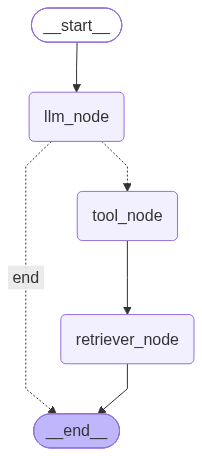

In [12]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("llm_node", llm_node)
graph.add_node("tool_node", tool_node)
graph.add_node("retriever_node", retriever_node)

graph.add_edge(START, "llm_node")
graph.add_conditional_edges("llm_node", tool_needed, {"tool_node": "tool_node", "end": END})
graph.add_edge("tool_node", "retriever_node")
graph.add_edge("retriever_node", END)

customer_support_agent = graph.compile()

customer_support_agent